# 3. Topic Modeling sur les Avis d'Assurance

 Ce notebook applique l'algorithme LDA pour identifier automatiquement les
       grands thèmes abordés dans les avis clients d'assurance.

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import pyLDAvis.gensim_models
import seaborn as sns
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from gensim.utils import simple_preprocess

from app.utils.spinner import run_with_spinner
from config import DATA_CLEAN, MODELS_DIR, CLEAN_COL

## 3.1 Chargement des données nettoyées

In [11]:
df = pd.read_csv(DATA_CLEAN)

## 3.2 Préparation du corpus pour LDA

In [12]:
def tokenize_for_lda(text):
    """Tokenise le texte déjà nettoyé pour LDA."""
    if pd.isna(text):
        return []
    return [t for t in simple_preprocess(str(text), deacc=True) if len(t) > 2]

In [13]:
texts = run_with_spinner(
    lambda: df[CLEAN_COL].apply(tokenize_for_lda).tolist(),
    msg="Tokenisation..."
)
print(f"Tokenisation terminée !")

Tokenisation terminée !


In [15]:
all_words = [w for doc in texts for w in doc]
print(f"Tokens totaux       : {len(all_words)}")
print(f"Vocabulaire unique  : {len(set(all_words))}")
print(f"Tokens moy/document : {len(all_words) / len(texts):.1f}")

Tokens totaux       : 471085
Vocabulaire unique  : 17094
Tokens moy/document : 19.5


In [17]:
dictionary = corpora.Dictionary(texts)
print(f"Dictionnaire avant filtrage : {len(dictionary)} mots")

dictionary.filter_extremes(no_below=5, no_above=0.5)
print(f"Dictionnaire après filtrage : {len(dictionary)} mots")

corpus_bow = [dictionary.doc2bow(text) for text in texts]
print(f"Corpus : {len(corpus_bow)} documents")

Dictionnaire avant filtrage : 17094 mots
Dictionnaire après filtrage : 4652 mots
Corpus : 24099 documents


In [19]:
# Exemple
print(f"Document 0 (5 premiers) :")
print([(dictionary[id_], freq) for id_, freq in corpus_bow[0][:5]])

Document 0 (5 premiers) :
[('assurance', 1), ('bien', 1), ('clair', 1), ('contacter', 1), ('expliquer', 1)]


## 3.3 Entraînement du modèle LDA

In [21]:
NUM_TOPICS = 6

lda_model = run_with_spinner(
    lambda: LdaModel(
        corpus=corpus_bow,
        id2word=dictionary,
        num_topics=NUM_TOPICS,
        random_state=42,
        passes=10,
        iterations=400,
        alpha='auto',
        eta='auto',
        per_word_topics=True,
    ),
    msg=f"Entraînement LDA (num_topics={NUM_TOPICS})..."
)
print("Entraînement terminé !")

Entraînement terminé !


In [24]:
print("Top 10 mots par topic")
for i, topic in lda_model.print_topics(num_topics=NUM_TOPICS, num_words=10):
    print(f"Topic {i}: {topic}")
    print()

Top 10 mots par topic
Topic 0: 0.044*"sinistre" + 0.037*"vehicule" + 0.025*"voiture" + 0.025*"etre" + 0.024*"expert" + 0.020*"assurer" + 0.020*"macif" + 0.017*"accident" + 0.017*"suite" + 0.017*"assurance"

Topic 1: 0.017*"mois" + 0.017*"contrat" + 0.014*"assurance" + 0.014*"faire" + 0.013*"aucun" + 0.013*"etre" + 0.012*"rien" + 0.010*"demande" + 0.010*"telephone" + 0.010*"remboursement"

Topic 2: 0.039*"annee" + 0.037*"assurance" + 0.031*"sinistre" + 0.023*"assurer" + 0.019*"bonus" + 0.018*"contrat" + 0.017*"euro" + 0.015*"cher" + 0.015*"vehicule" + 0.014*"client"

Topic 3: 0.035*"mutuel" + 0.016*"sante" + 0.015*"juridique" + 0.014*"arret" + 0.014*"remboursement" + 0.012*"protection" + 0.011*"aide" + 0.010*"travail" + 0.010*"maladie" + 0.009*"mutuelle"

Topic 4: 0.083*"charge" + 0.058*"prise" + 0.020*"prendre" + 0.014*"expertise" + 0.013*"excellent" + 0.011*"mgp" + 0.010*"entourage" + 0.010*"apporter" + 0.009*"plaisir" + 0.009*"maison"

Topic 5: 0.055*"service" + 0.047*"prix" + 0.042*

## 3.4 Identification des topics

In [25]:
TOPIC_LABELS = {
    0: 'Sinistres Auto',
    1: 'Problèmes & Litiges',
    2: 'Tarifs & Contrats',
    3: 'Assurance Santé',
    4: 'Prise en Charge',
    5: 'Satisfaction Client',
}

In [26]:
print("Analyse des topics")
for topic_id in range(NUM_TOPICS):
    words = lda_model.show_topic(topic_id, topn=10)
    word_str = ', '.join([f"{w}({s:.3f})" for w, s in words])
    print(f"Topic {topic_id} → {TOPIC_LABELS[topic_id]}")
    print(f"  {word_str}\n")

Analyse des topics
Topic 0 → Sinistres Auto
  sinistre(0.044), vehicule(0.037), voiture(0.025), etre(0.025), expert(0.024), assurer(0.020), macif(0.020), accident(0.017), suite(0.017), assurance(0.017)

Topic 1 → Problèmes & Litiges
  mois(0.017), contrat(0.017), assurance(0.014), faire(0.014), aucun(0.013), etre(0.013), rien(0.012), demande(0.010), telephone(0.010), remboursement(0.010)

Topic 2 → Tarifs & Contrats
  annee(0.039), assurance(0.037), sinistre(0.031), assurer(0.023), bonus(0.019), contrat(0.018), euro(0.017), cher(0.015), vehicule(0.015), client(0.014)

Topic 3 → Assurance Santé
  mutuel(0.035), sante(0.016), juridique(0.015), arret(0.014), remboursement(0.014), protection(0.012), aide(0.011), travail(0.010), maladie(0.010), mutuelle(0.009)

Topic 4 → Prise en Charge
  charge(0.083), prise(0.058), prendre(0.020), expertise(0.014), excellent(0.013), mgp(0.011), entourage(0.010), apporter(0.010), plaisir(0.009), maison(0.009)

Topic 5 → Satisfaction Client
  service(0.055)

## 3.5 Cohérence du modèle

In [29]:
cv_score = run_with_spinner(
    lambda: CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    ).get_coherence(),
    msg="Calcul du score de cohérence C_V..."
)
print(f"Score de cohérence C_V : {cv_score:.4f}")

Score de cohérence C_V : 0.5128


In [31]:
def search_coherence():
    values = []
    for n in n_range:
        m = LdaModel(corpus=corpus_bow, id2word=dictionary,
                     num_topics=n, random_state=42, passes=5, iterations=100)
        cm = CoherenceModel(model=m, texts=texts, dictionary=dictionary, coherence='c_v')
        values.append(cm.get_coherence())
    return values

In [32]:
n_range = list(range(2, 13, 2))

coherence_values = run_with_spinner(
    search_coherence,
    msg=f"Recherche du nombre optimal de topics {n_range}..."
)
print(f"Recherche du nombre optimal de topics terminée !")

Recherche du nombre optimal de topics terminée !


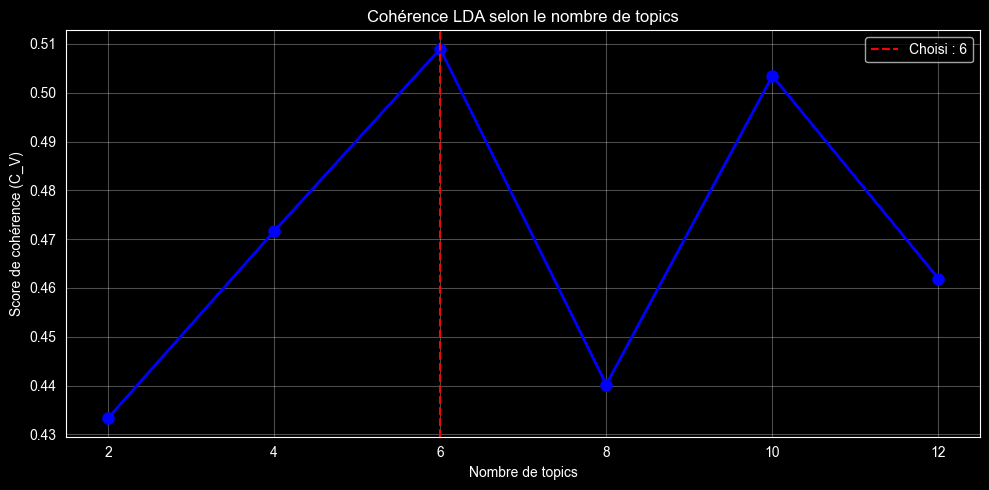

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(n_range, coherence_values, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=NUM_TOPICS, color='r', linestyle='--', label=f'Choisi : {NUM_TOPICS}')
plt.xlabel('Nombre de topics')
plt.ylabel('Score de cohérence (C_V)')
plt.title('Cohérence LDA selon le nombre de topics')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3.6 Visualisation pyLDAvis

In [38]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus_bow, dictionary, sort_topics=False)
pyLDAvis.save_html(vis, str(MODELS_DIR / 'lda_visualization.html'))
print(f"{MODELS_DIR / 'lda_visualization.html'}")
pyLDAvis.display(vis)

✅ Sauvegardé : /Users/amaitre/prive/4_ECOLE/S8/NLP/projet2/models/lda_visualization.html


## 3.7 Attribution des topics aux reviews

In [ ]:
def get_dominant_topic(bow):
    probs = lda_model.get_document_topics(bow)
    if not probs:
        return 0, 0.0
    top = max(probs, key=lambda x: x[1])
    return top[0], float(top[1])

In [18]:
print("Attribution des topics...")
assignments = [get_dominant_topic(bow) for bow in corpus_bow]
df['topic_id'] = [a[0] for a in assignments]
df['topic_prob'] = [a[1] for a in assignments]
df['topic_label'] = df['topic_id'].map(TOPIC_LABELS)

print("\nDistribution des topics :")
print(df['topic_label'].value_counts())

Attribution des topics...

Distribution des topics :
topic_label
Enrollment Process     10159
Pricing & Cost          3963
Customer Service        3962
Claims Processing       3166
Coverage & Benefits     1184
Cancellation            1082
Name: count, dtype: int64


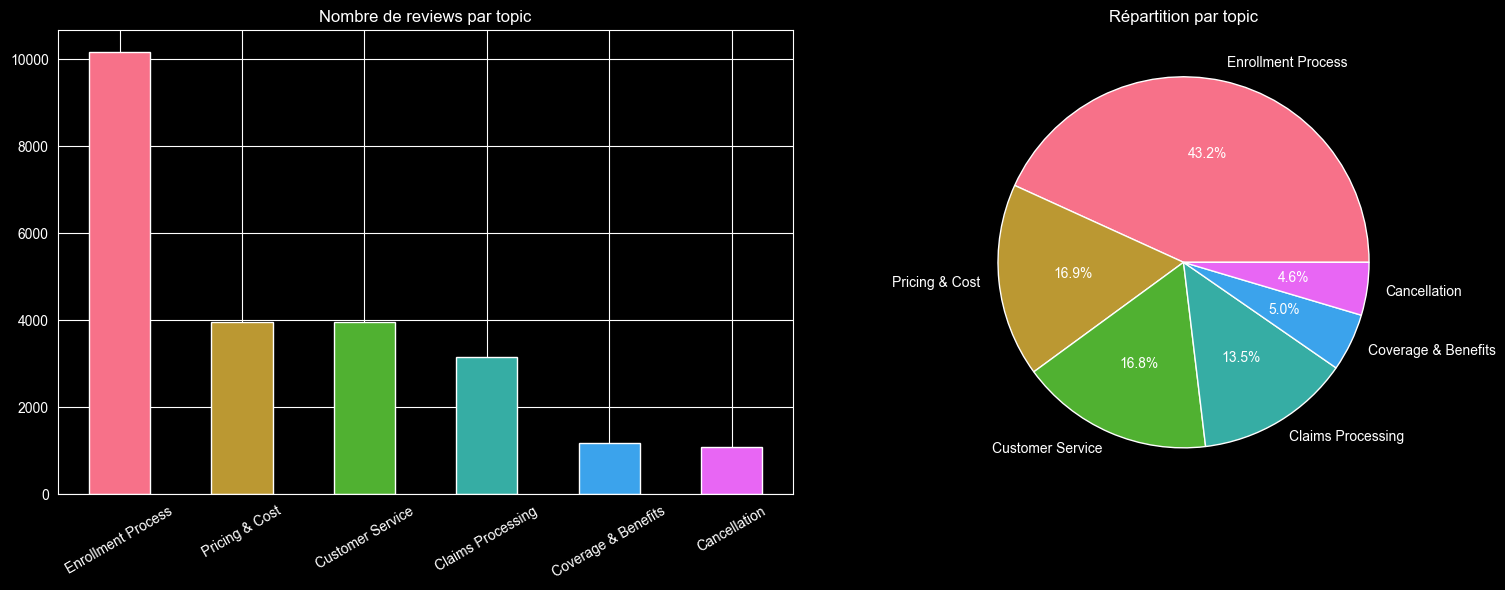

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = sns.color_palette('husl', NUM_TOPICS)

topic_counts = df['topic_label'].value_counts()
topic_counts.plot(kind='bar', ax=axes[0], color=palette)
axes[0].set_title('Nombre de reviews par topic')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(topic_counts.values, labels=topic_counts.index, autopct='%1.1f%%', colors=palette)
axes[1].set_title('Répartition par topic')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'topic_distribution.png', dpi=100)
plt.show()

In [20]:
text_display = 'review' if 'review' in df.columns else text_col
print("=== Exemples de reviews par topic ===")
for tid, label in TOPIC_LABELS.items():
    reviews = df[df['topic_id'] == tid][text_display].dropna()
    print(f"\n{'=' * 55}")
    print(f"Topic {tid}: {label}  ({len(reviews)} reviews)")
    print('=' * 55)
    for i, r in enumerate(reviews.head(2), 1):
        print(f"  [{i}] {str(r)[:200]}...")

=== Exemples de reviews par topic ===

Topic 0: Pricing & Cost  (3963 reviews)
  [1] Hello, currently I am at Active Insurance under the number 164900 and for almost a year my new insurance has been trying to terminate with the Hamon laws without success each time it is missing a truc...
  [2]  My mother has died for several months and still no reversion (missing piece ... My sister received her share 2 days ago and the files were sent in the same mail - look for the error)...

Topic 1: Coverage & Benefits  (1184 reviews)
  [1] The year of my subscription I got a good price being a good 50 % for 2 years.
My big surprise the following year was to see my premium increased by more than 8% when I had no claim and the confinement...
  [2] Hello,
I have just made a change of contract holder on a contract of less than 30 days,
This leads to its termination and a new subscription and I am refused the 20% reduction (family offer 50% bonus)...

Topic 2: Enrollment Process  (10159 reviews)
  [1] 

## 3.8 Analyse croisée topics × étoiles

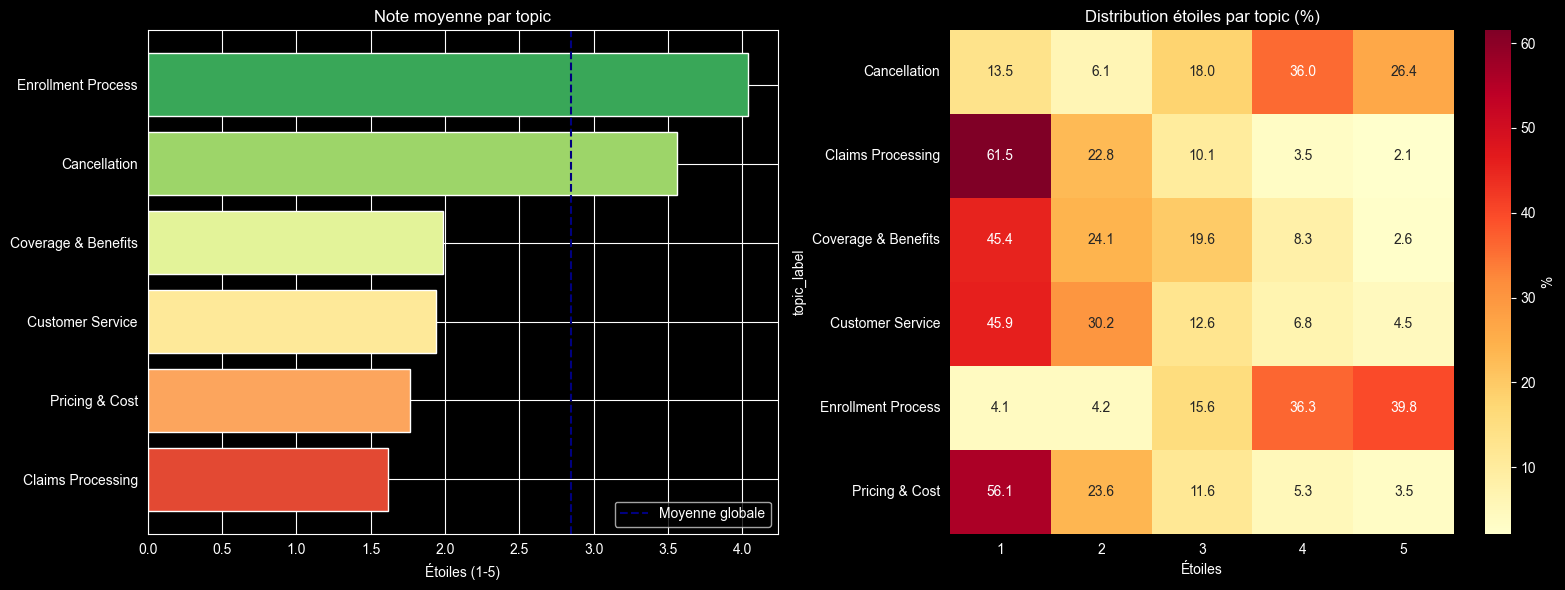

In [21]:
if 'stars' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    avg_stars = df.groupby('topic_label')['stars'].mean().sort_values()
    colors = sns.color_palette('RdYlGn', len(avg_stars))
    axes[0].barh(avg_stars.index, avg_stars.values, color=colors)
    axes[0].axvline(df['stars'].mean(), color='navy', linestyle='--', label='Moyenne globale')
    axes[0].set_title('Note moyenne par topic')
    axes[0].set_xlabel('Étoiles (1-5)')
    axes[0].legend()

    pivot = df.groupby(['topic_label', 'stars']).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
                cbar_kws={'label': '%'})
    axes[1].set_title('Distribution étoiles par topic (%)')
    axes[1].set_xlabel('Étoiles')

    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'topic_stars_heatmap.png', dpi=100)
    plt.show()
else:
    print("Colonne 'stars' non disponible")

## 3.9 Sauvegarde

In [22]:
# Sauvegarder modèle et dictionnaire
lda_model.save(str(MODELS_DIR / 'lda_model'))
dictionary.save(str(MODELS_DIR / 'lda_dictionary'))
print(f"✅ Modèle LDA    : {MODELS_DIR / 'lda_model'}")

# Sauvegarder dataset enrichi
out_path = DATA_PROCESSED / 'reviews_topics.csv'
df.to_csv(out_path, index=False)
print(f"✅ Dataset topics : {out_path}")
print(f"   Shape  : {df.shape}")
print(f"   Colonnes ajoutées : topic_id, topic_prob, topic_label")
df[['topic_id', 'topic_label', 'topic_prob']].head(5)

✅ Modèle LDA    : /Users/amaitre/prive/4_ECOLE/S8/NLP/projet2/models/lda_model
✅ Dataset topics : /Users/amaitre/prive/4_ECOLE/S8/NLP/projet2/data/processed/reviews_topics.csv
   Shape  : (23516, 13)
   Colonnes ajoutées : topic_id, topic_prob, topic_label


,topic_id,topic_label,topic_prob
0,5,Cancellation,0.474494
1,2,Enrollment Process,0.875752
2,3,Customer Service,0.523039
3,3,Customer Service,0.433852
4,2,Enrollment Process,0.594643


## 3.10 Analyse de la distribution des probabilités de topic

On examine ici la distribution des probabilités d'appartenance au topic dominant pour chaque document.
Un score élevé indique que le document est fortement associé à un seul topic (thème clair),
tandis qu'un score faible indique un document ambigu appartenant à plusieurs topics à la fois.

On analyse également les documents dits "mixtes" — ceux dont la probabilité du topic dominant
est inférieure à 0.4 — pour comprendre s'ils forment des thèmes de transition ou simplement
des avis généralistes.

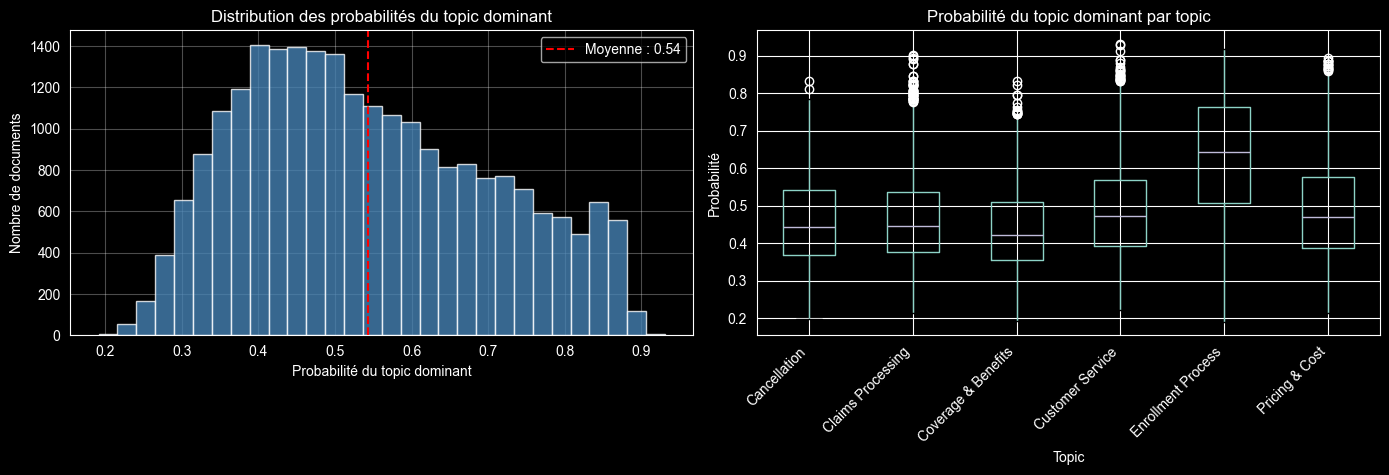


Documents ambigus (topic_prob < 0.4) : 5113 (21.7%)
Documents clairement assignés (topic_prob >= 0.4) : 18403 (78.3%)

Stats sur topic_prob :
count    23516.0000
mean         0.5431
std          0.1612
min          0.1912
25%          0.4138
50%          0.5204
75%          0.6647
max          0.9309
Name: topic_prob, dtype: float64


In [23]:
# Distribution des probabilités du topic dominant
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme global de topic_prob
axes[0].hist(df['topic_prob'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=df['topic_prob'].mean(), color='red', linestyle='--',
                label=f"Moyenne : {df['topic_prob'].mean():.2f}")
axes[0].set_title('Distribution des probabilités du topic dominant')
axes[0].set_xlabel('Probabilité du topic dominant')
axes[0].set_ylabel('Nombre de documents')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot par topic
df.boxplot(column='topic_prob', by='topic_label', ax=axes[1])
axes[1].set_title('Probabilité du topic dominant par topic')
axes[1].set_xlabel('Topic')
axes[1].set_ylabel('Probabilité')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'topic_prob_distribution.png', dpi=100)
plt.show()

# Documents "mixtes" (faible certitude d'appartenance à un topic)
threshold = 0.4
mixed_docs = df[df['topic_prob'] < threshold]
print(f"\nDocuments ambigus (topic_prob < {threshold}) : {len(mixed_docs)} ({len(mixed_docs) / len(df) * 100:.1f}%)")
print(
    f"Documents clairement assignés (topic_prob >= {threshold}) : {len(df) - len(mixed_docs)} ({(len(df) - len(mixed_docs)) / len(df) * 100:.1f}%)")

print(f"\nStats sur topic_prob :")
print(df['topic_prob'].describe().round(4))